In [2]:
# Check your GPU
!nvidia-smi

# Check available RAM and disk
import psutil, shutil
ram = psutil.virtual_memory()
disk = shutil.disk_usage("/")
print(f"\nRAM: {ram.total / 1e9:.1f} GB total, {ram.available / 1e9:.1f} GB available")
print(f"Disk: {disk.total / 1e9:.1f} GB total, {disk.free / 1e9:.1f} GB free")

Tue Apr 28 03:21:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Create a project folder
import os
os.makedirs('/content/drive/MyDrive/svg_project', exist_ok=True)
os.makedirs('/content/drive/MyDrive/svg_project/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/svg_project/checkpoints', exist_ok=True)
print("✅ Google Drive mounted and project folders created!")

Mounted at /content/drive
✅ Google Drive mounted and project folders created!


In [ ]:
# Install all libraries we need for the whole project
!pip install datasets tokenizers lxml cairosvg sentencepiece -q

# Verify installs
import datasets, tokenizers, lxml, cairosvg
print("✅ datasets:", datasets.__version__)
print("✅ tokenizers:", tokenizers.__version__)
print("✅ lxml installed")
print("✅ cairosvg installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 8.1 MB/s eta 0:00:00
✅ datasets: 4.0.0
✅ tokenizers: 0.22.2
✅ lxml installed
✅ cairosvg installed


In [ ]:
from datasets import load_dataset

print("Loading dataset... (this may take 2-3 minutes)")
ds = load_dataset("starvector/svg-icons-simple")
print("\n✅ Dataset loaded!")
print(ds)

Loading dataset... (this may take 2-3 minutes)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/137M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.59M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/11.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/80434 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2682 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/6254 [00:00<?, ? examples/s]


✅ Dataset loaded!
DatasetDict({
    train: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 80434
    })
    test: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 2682
    })
    val: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 6254
    })
})


In [ ]:
# Look at the first SVG correctly
sample = ds['train'][0]
print("Keys:", sample.keys())
print("Filename:", sample['Filename'])
print("\n--- SVG content (first 500 chars) ---")
print(sample['Svg'][:500])
print("\nTotal SVG length:", len(sample['Svg']), "characters")

Keys: dict_keys(['Filename', 'Svg'])
Filename: 78042

--- SVG content (first 500 chars) ---
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432 C10.977089881896973 7.366771697998047 14.58566665649414 7.627137660980225 14.384374618530273 9.36875057220459 C14.17175006866455 11.208415031433105 10.620377540588379 11.302374839782715 9.46875 11.240625381469727 C8.640908241271973 11.1962

Total SVG length: 2235 characters


In [ ]:
import re
from lxml import etree

def clean_svg(svg_string):
    """Clean and normalize an SVG string."""

    # 1. Strip XML comments
    svg_string = re.sub(r'<!--.*?-->', '', svg_string, flags=re.DOTALL)

    # 2. Remove extra whitespace (newlines, tabs, multiple spaces)
    svg_string = re.sub(r'\s+', ' ', svg_string).strip()

    # 3. Round all numbers to 1 decimal place
    def round_number(match):
        try:
            return str(round(float(match.group()), 1))
        except:
            return match.group()
    svg_string = re.sub(r'-?\d+\.\d+', round_number, svg_string)

    return svg_string

def is_valid_xml(svg_string):
    """Check if string is valid XML."""
    try:
        etree.fromstring(svg_string.encode())
        return True
    except:
        return False

def is_valid_length(svg_string, min_chars=50, max_chars=8000):
    """Filter by character length (proxy for token length)."""
    return min_chars <= len(svg_string) <= max_chars

# Test on our sample
raw = ds['train'][0]['Svg']
cleaned = clean_svg(raw)

print("=== BEFORE CLEANING ===")
print(raw[:300])
print(f"\nLength: {len(raw)} chars")

print("\n=== AFTER CLEANING ===")
print(cleaned[:300])
print(f"\nLength: {len(cleaned)} chars")

print("\n=== VALIDATION ===")
print("Valid XML?", is_valid_xml(cleaned))
print("Valid length?", is_valid_length(cleaned))

=== BEFORE CLEANING ===
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432 C10.977089881896973 7.366771697998047 1

Length: 2235 chars

=== AFTER CLEANING ===
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M10.1 7.3 L10.1 7.3 C11.0 7.4 14.6 7.6 14.4 9.4 C14.2 11.2 10.6 11.3 9.5 11.2 C8.6 11.2 4.8 10.6 5.7 8.7 C6.3 7.5 9.

Length: 949 chars

=== VALIDATION ===
Valid XML? True
Valid length? True


In [ ]:
print("Cleaning all SVGs... this may take a few minutes")

cleaned_svgs = []
stats = {"total": 0, "too_short": 0, "too_long": 0, "invalid_xml": 0, "kept": 0}

for item in ds['train']:
    stats['total'] += 1
    svg = item['Svg']

    # Length filter first (cheap)
    if not is_valid_length(svg):
        if len(svg) < 50:
            stats['too_short'] += 1
        else:
            stats['too_long'] += 1
        continue

    # Clean it
    svg = clean_svg(svg)

    # XML validation (more expensive)
    if not is_valid_xml(svg):
        stats['invalid_xml'] += 1
        continue

    cleaned_svgs.append(svg)
    stats['kept'] += 1

    # Progress update every 10k
    if stats['total'] % 10000 == 0:
        print(f"  Processed {stats['total']:,}...")

print("\n✅ Done!")
print(f"  Total:       {stats['total']:,}")
print(f"  Too short:   {stats['too_short']:,}")
print(f"  Too long:    {stats['too_long']:,}")
print(f"  Invalid XML: {stats['invalid_xml']:,}")
print(f"  Kept:        {stats['kept']:,} ({stats['kept']/stats['total']*100:.1f}%)")

Cleaning all SVGs... this may take a few minutes
  Processed 10,000...
  Processed 20,000...
  Processed 40,000...
  Processed 70,000...
  Processed 80,000...

✅ Done!
  Total:       80,434
  Too short:   0
  Too long:    15,623
  Invalid XML: 0
  Kept:        64,811 (80.6%)


In [ ]:
# Load supplementary emoji dataset
print("Loading emoji dataset...")
ds_emoji = load_dataset("starvector/svg-emoji-simple")
print(ds_emoji)

# Clean it the same way
emoji_svgs = []
emoji_stats = {"total": 0, "kept": 0}

for item in ds_emoji['train']:
    emoji_stats['total'] += 1
    svg = item['Svg']

    if not is_valid_length(svg):
        continue
    svg = clean_svg(svg)
    if not is_valid_xml(svg):
        continue

    emoji_svgs.append(svg)
    emoji_stats['kept'] += 1

print(f"\n✅ Emoji dataset: kept {emoji_stats['kept']:,} / {emoji_stats['total']:,}")

# Combine both datasets
all_svgs = cleaned_svgs + emoji_svgs
print(f"\nTotal SVGs combined: {len(all_svgs):,}")

total_chars = sum(len(svg) for svg in all_svgs)
estimated_tokens = total_chars / 4
print(f"Estimated tokens: {estimated_tokens/1e6:.1f}M")

Loading emoji dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/12.7M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/687k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4114 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/646 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/346 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 4114
    })
    test: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 646
    })
    val: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 346
    })
})

✅ Emoji dataset: kept 1,965 / 4,114

Total SVGs combined: 66,776
Estimated tokens: 26.5M


In [ ]:
# We need ~73M more tokens
# Load svg-fonts-simple but subsample it (it's 2.38GB, we don't need all of it)

print("Loading fonts dataset (streaming mode to avoid downloading all 2.38GB)...")
ds_fonts = load_dataset("starvector/svg-fonts-simple", split="train", streaming=True)

font_svgs = []
font_stats = {"processed": 0, "kept": 0}
TARGET = 200000  # process up to 200k, stop early if we hit token target

for item in ds_fonts:
    font_stats['processed'] += 1
    svg = item['Svg']

    if not is_valid_length(svg):
        continue
    svg = clean_svg(svg)
    if not is_valid_xml(svg):
        continue

    font_svgs.append(svg)
    font_stats['kept'] += 1

    # Progress update
    if font_stats['processed'] % 20000 == 0:
        current_chars = sum(len(s) for s in font_svgs)
        current_tokens = (sum(len(s) for s in all_svgs) + current_chars) / 4
        print(f"  Processed {font_stats['processed']:,} | kept {font_stats['kept']:,} | total ~{current_tokens/1e6:.1f}M tokens")

        # Stop if we have enough
        if current_tokens >= 110_000_000:
            print("✅ Reached 110M token target, stopping early!")
            break

    if font_stats['processed'] >= TARGET:
        print(f"Reached {TARGET:,} limit")
        break

print(f"\nFont SVGs kept: {font_stats['kept']:,} / {font_stats['processed']:,}")

# Combine everything
all_svgs = cleaned_svgs + emoji_svgs + font_svgs
total_chars = sum(len(svg) for svg in all_svgs)
estimated_tokens = total_chars / 4
print(f"Total SVGs: {len(all_svgs):,}")
print(f"Estimated tokens: {estimated_tokens/1e6:.1f}M")

Loading fonts dataset (streaming mode to avoid downloading all 2.38GB)...


README.md: 0.00B [00:00, ?B/s]

  Processed 20,000 | kept 19,909 | total ~30.5M tokens
  Processed 40,000 | kept 39,816 | total ~34.4M tokens
  Processed 60,000 | kept 59,710 | total ~38.4M tokens
  Processed 80,000 | kept 79,612 | total ~42.3M tokens
  Processed 100,000 | kept 99,528 | total ~46.3M tokens
  Processed 140,000 | kept 139,346 | total ~54.2M tokens
  Processed 160,000 | kept 159,253 | total ~58.1M tokens
  Processed 180,000 | kept 179,162 | total ~62.1M tokens
  Processed 200,000 | kept 199,064 | total ~66.0M tokens
Reached 200,000 limit

Font SVGs kept: 199,064 / 200,000
Total SVGs: 265,840
Estimated tokens: 66.0M


In [ ]:
# Fonts are tiny SVGs. Let's get more fonts + load svg-stack dataset
print("Getting more font SVGs + loading svg-stack dataset...\n")

# Continue getting more fonts
ds_fonts2 = load_dataset("starvector/svg-fonts-simple", split="train", streaming=True)

more_font_svgs = []
TARGET2 = 500000  # get up to 500k this time

for item in ds_fonts2:
    svg = item['Svg']
    if not is_valid_length(svg):
        continue
    svg = clean_svg(svg)
    if not is_valid_xml(svg):
        continue
    more_font_svgs.append(svg)

    if len(more_font_svgs) % 50000 == 0:
        print(f"  Fonts collected: {len(more_font_svgs):,}")

    if len(more_font_svgs) >= TARGET2:
        print(f"✅ Reached {TARGET2:,} font SVGs")
        break

print(f"\nExtra fonts collected: {len(more_font_svgs):,}")

# Also load svg-stack (larger/more diverse SVGs)
print("\nLoading svg-stack dataset (streaming)...")
ds_stack = load_dataset("starvector/svg-stack-simple", split="train", streaming=True)

stack_svgs = []
for item in ds_stack:
    svg = item['Svg']
    if not is_valid_length(svg):
        continue
    svg = clean_svg(svg)
    if not is_valid_xml(svg):
        continue
    stack_svgs.append(svg)

    if len(stack_svgs) % 10000 == 0:
        # Check total tokens so far
        all_combined = cleaned_svgs + emoji_svgs + font_svgs + more_font_svgs + stack_svgs
        total_tokens = sum(len(s) for s in all_combined) / 4
        print(f"  Stack collected: {len(stack_svgs):,} | Total tokens: ~{total_tokens/1e6:.1f}M")

        if total_tokens >= 110_000_000:
            print("✅ Hit 110M token target!")
            break

# Final combined dataset
all_svgs = cleaned_svgs + emoji_svgs + font_svgs + more_font_svgs + stack_svgs
total_chars = sum(len(svg) for svg in all_svgs)
estimated_tokens = total_chars / 4

print(f"\n{'='*40}")
print(f"Icons:       {len(cleaned_svgs):,}")
print(f"Emoji:       {len(emoji_svgs):,}")
print(f"Fonts:       {len(font_svgs) + len(more_font_svgs):,}")
print(f"Stack:       {len(stack_svgs):,}")
print(f"{'='*40}")
print(f"TOTAL SVGs:  {len(all_svgs):,}")
print(f"EST. TOKENS: {estimated_tokens/1e6:.1f}M")

Getting more font SVGs + loading svg-stack dataset...

  Fonts collected: 50,000
  Fonts collected: 100,000
  Fonts collected: 150,000
  Fonts collected: 200,000
  Fonts collected: 250,000
  Fonts collected: 300,000
  Fonts collected: 350,000
  Fonts collected: 400,000
  Fonts collected: 450,000
  Fonts collected: 500,000
✅ Reached 500,000 font SVGs

Extra fonts collected: 500,000

Loading svg-stack dataset (streaming)...


README.md: 0.00B [00:00, ?B/s]

  Stack collected: 10,000 | Total tokens: ~168.5M
✅ Hit 110M token target!

Icons:       64,811
Emoji:       1,965
Fonts:       699,064
Stack:       10,000
TOTAL SVGs:  775,840
EST. TOKENS: 168.5M


In [ ]:
#Saving the cleaned data to drive

import json
import random

# Shuffle before splitting (important!)
random.seed(42)
random.shuffle(all_svgs)

# 98/1/1 split
total = len(all_svgs)
train_end = int(0.98 * total)
val_end = int(0.99 * total)

train_svgs = all_svgs[:train_end]
val_svgs   = all_svgs[train_end:val_end]
test_svgs  = all_svgs[val_end:]

print(f"Train: {len(train_svgs):,} SVGs")
print(f"Val:   {len(val_svgs):,} SVGs")
print(f"Test:  {len(test_svgs):,} SVGs")

# Save all splits to Drive
print("\nSaving to Google Drive (this may take a minute)...")
base = '/content/drive/MyDrive/svg_project/data'

with open(f'{base}/train_svgs.json', 'w') as f:
    json.dump(train_svgs, f)
print("✅ train saved")

with open(f'{base}/val_svgs.json', 'w') as f:
    json.dump(val_svgs, f)
print("✅ val saved")

with open(f'{base}/test_svgs.json', 'w') as f:
    json.dump(test_svgs, f)
print("✅ test saved")

print(f"\n🎉 All splits saved to Drive!")
print(f"Train tokens: ~{sum(len(s) for s in train_svgs)/4/1e6:.1f}M")
print(f"Val tokens:   ~{sum(len(s) for s in val_svgs)/4/1e6:.1f}M")
print(f"Test tokens:  ~{sum(len(s) for s in test_svgs)/4/1e6:.1f}M")

Train: 760,323 SVGs
Val:   7,758 SVGs
Test:  7,759 SVGs

Saving to Google Drive (this may take a minute)...
✅ train saved
✅ val saved
✅ test saved

🎉 All splits saved to Drive!
Train tokens: ~165.1M
Val tokens:   ~1.7M
Test tokens:  ~1.7M


In [ ]:
# PART 1 - STEP 1.9: Train BPE Tokenizer
from tokenizers import ByteLevelBPETokenizer
import os

base = '/content/drive/MyDrive/svg_project/data'

# Save train SVGs to a text file (tokenizer trains on raw text)
print("Writing training text file...")
tokenizer_input = '/content/train_text.txt'
with open(tokenizer_input, 'w') as f:
    for svg in train_svgs:
        f.write(svg + '\n')
print(f"✅ Written {len(train_svgs):,} SVGs to text file")

# Train BPE tokenizer
print("\nTraining BPE tokenizer (vocab size = 4096)...")
tokenizer = ByteLevelBPETokenizer()
tokenizer.train(
    files=[tokenizer_input],
    vocab_size=4096,
    min_frequency=2,
    special_tokens=["<pad>", "<s>", "</s>", "<unk>"]
)

# Save tokenizer to Drive
tokenizer_dir = f'{base}/tokenizer'
os.makedirs(tokenizer_dir, exist_ok=True)
tokenizer.save_model(tokenizer_dir)
print(f"✅ Tokenizer saved to Drive!")

# Quick test
test_svg = train_svgs[0]
encoded = tokenizer.encode(test_svg)
print(f"\n--- Tokenizer Test ---")
print(f"SVG length:    {len(test_svg)} chars")
print(f"Token count:   {len(encoded.ids)}")
print(f"First 20 tokens: {encoded.ids[:20]}")
print(f"Decoded back:  {tokenizer.decode(encoded.ids)[:100]}")

Writing training text file...
✅ Written 760,323 SVGs to text file

Training BPE tokenizer (vocab size = 4096)...
✅ Tokenizer saved to Drive!

--- Tokenizer Test ---
SVG length:    493 chars
Token count:   242
First 20 tokens: [31, 302, 364, 261, 358, 339, 359, 17, 90, 22, 17, 361, 18, 357, 18, 302, 5, 363, 261, 19]
Decoded back:  <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><pa


Computing statistics... (may take a minute)
Counting tokens on sample...

DATASET STATISTICS
Vocabulary size:        4,096
Total SVGs:             775,840
  Train SVGs:           760,323 (98%)
  Val SVGs:             7,758 (1%)
  Test SVGs:            7,759 (1%)
Avg tokens per SVG:     475
Est. train tokens:      361.1M
Est. val tokens:        3.7M
Est. test tokens:       3.7M


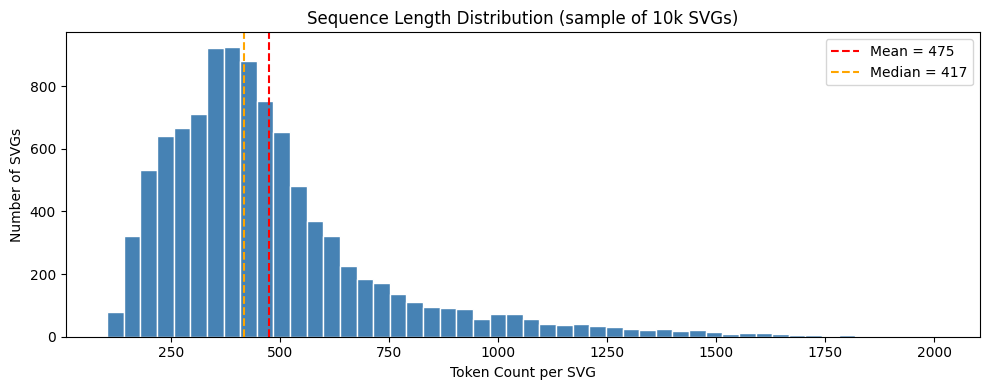

✅ Histogram saved to Drive!

Rendering 3 example SVGs...


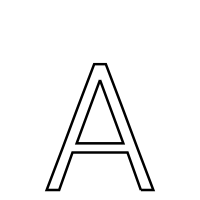

Example 1: 493 chars, 242 tokens


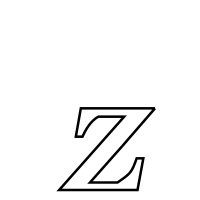

Example 2: 421 chars, 219 tokens


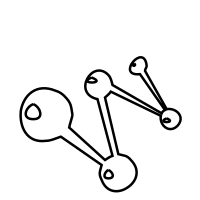

Example 3: 1715 chars, 917 tokens

✅ PART 1 COMPLETE!


In [ ]:
# PART 1 - STEP 1.10: Dataset Statistics
import matplotlib.pyplot as plt
import numpy as np

print("Computing statistics... (may take a minute)")

# Token counts for each split
def count_tokens(svgs, sample_size=10000):
    """Count tokens on a sample for speed"""
    sample = svgs[:sample_size]
    counts = [len(tokenizer.encode(s).ids) for s in sample]
    return counts

print("Counting tokens on sample...")
train_token_counts = count_tokens(train_svgs)
avg_tokens = np.mean(train_token_counts)
total_train_tokens = avg_tokens * len(train_svgs)
total_val_tokens   = avg_tokens * len(val_svgs)
total_test_tokens  = avg_tokens * len(test_svgs)

print(f"\n{'='*45}")
print(f"DATASET STATISTICS")
print(f"{'='*45}")
print(f"Vocabulary size:        4,096")
print(f"Total SVGs:             {len(train_svgs)+len(val_svgs)+len(test_svgs):,}")
print(f"  Train SVGs:           {len(train_svgs):,} (98%)")
print(f"  Val SVGs:             {len(val_svgs):,} (1%)")
print(f"  Test SVGs:            {len(test_svgs):,} (1%)")
print(f"Avg tokens per SVG:     {avg_tokens:.0f}")
print(f"Est. train tokens:      {total_train_tokens/1e6:.1f}M")
print(f"Est. val tokens:        {total_val_tokens/1e6:.1f}M")
print(f"Est. test tokens:       {total_test_tokens/1e6:.1f}M")
print(f"{'='*45}")

# Plot sequence length histogram
plt.figure(figsize=(10, 4))
plt.hist(train_token_counts, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Token Count per SVG')
plt.ylabel('Number of SVGs')
plt.title('Sequence Length Distribution (sample of 10k SVGs)')
plt.axvline(np.mean(train_token_counts), color='red',
            linestyle='--', label=f'Mean = {np.mean(train_token_counts):.0f}')
plt.axvline(np.median(train_token_counts), color='orange',
            linestyle='--', label=f'Median = {np.median(train_token_counts):.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svg_project/data/sequence_length_hist.png', dpi=150)
plt.show()
print("✅ Histogram saved to Drive!")

# Show 3 example SVGs rendered
print("\nRendering 3 example SVGs...")
import cairosvg, base64
from IPython.display import display, Image

for i, idx in enumerate([0, len(train_svgs)//2, -1]):
    svg = train_svgs[idx]
    try:
        png = cairosvg.svg2png(bytestring=svg.encode())
        display(Image(png))
        print(f"Example {i+1}: {len(svg)} chars, "
              f"{len(tokenizer.encode(svg).ids)} tokens")
    except Exception as e:
        print(f"Example {i+1}: render failed ({e})")

print("\n✅ PART 1 COMPLETE!")

## Part 2: Transformer Scaling Study

In this section, we train 5 decoder-only transformer language models of increasing size (1M to 88M parameters) on our SVG dataset. We perform a learning rate sweep on the smallest model, then train all models with the best learning rate for 1 epoch to empirically derive scaling laws relating model size to validation loss.

In [ ]:
#PART 2 - Step 2.1: Clone nanoGPT and install dependencies

!git clone https://github.com/karpathy/nanoGPT.git
!pip install transformer -q

import sys
sys.path.insert(0, '/content/nanoGPT')

print ("nanoGPT cloned")
!ls /content/nanoGPT


Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.25 KiB | 3.08 MiB/s, done.
Resolving deltas: 100% (382/382), done.
ERROR: Could not find a version that satisfies the requirement transformer (from versions: none)
ERROR: No matching distribution found for transformer
nanoGPT cloned
assets	  configurator.py  model.py   scaling_laws.ipynb
bench.py  data		   README.md  train.py
config	  LICENSE	   sample.py  transformer_sizing.ipynb


In [ ]:
# PART 2 - STEP 2.2 FIX: Load everything back into memory
import json, re, os
from lxml import etree
from tokenizers import ByteLevelBPETokenizer

base = '/content/drive/MyDrive/svg_project/data'

# Load SVG splits
print("Loading SVGs from Drive...")
with open(f'{base}/train_svgs.json') as f:
    train_svgs = json.load(f)
with open(f'{base}/val_svgs.json') as f:
    val_svgs = json.load(f)
with open(f'{base}/test_svgs.json') as f:
    test_svgs = json.load(f)
print(f"✅ Train: {len(train_svgs):,} | Val: {len(val_svgs):,} | Test: {len(test_svgs):,}")

# Load tokenizer
print("\nLoading tokenizer...")
tokenizer = ByteLevelBPETokenizer(
    f'{base}/tokenizer/vocab.json',
    f'{base}/tokenizer/merges.txt'
)
print("✅ Tokenizer loaded!")

Loading SVGs from Drive...
✅ Train: 760,323 | Val: 7,758 | Test: 7,759

Loading tokenizer...
✅ Tokenizer loaded!


In [ ]:
#PART 2 - Step 2.2 : Convert tokenized SVG to binary format

import numpy as np
import os
from tokenizers import ByteLevelBPETokenizer

#Reload the tokenizers from drive


tokenizer = ByteLevelBPETokenizer ('/content/drive/MyDrive/svg_project/data/tokenizer/vocab.json',
    '/content/drive/MyDrive/svg_project/data/tokenizer/merges.txt'
)

print ('Tkenizers loaded')

#Tokenize all splits and save as binary

def tokenize_and_save (svgs, split_name):
  print (f"Tokenizing {split_name}({len(svgs):,}SVGS)...")
  all_tokens=[]
  for i,svg in enumerate (svgs):
    tokens= tokenizer.encode(svg).ids
    tokens.append(0)
    all_tokens.extend(tokens)
    if i % 100000 == 0 and i > 0:
       print (f"{i:,} done")

  #Saving as unit16 binary -> required for nanoGPT

  arr= np.array (all_tokens, dtype=np.uint16)
  out_path= f"/content/drive/MyDrive/svg_project/data/{split_name}.bin"
  arr.tofile(out_path)
  print (f"Saved to {out_path}")
  return len (all_tokens)

train_count = tokenize_and_save (train_svgs, 'train')
val_count = tokenize_and_save (val_svgs, 'val')
test_count = tokenize_and_save (test_svgs, 'test')

print(f"\n{'='*40}")
print(f"Train tokens: {train_count/1e6:.1f}M")
print(f"Val tokens:   {val_count/1e6:.1f}M")
print(f"Test tokens:  {test_count/1e6:.1f}M")
print(f"Total:        {(train_count+val_count+test_count)/1e6:.1f}M")
print(f"Data ready for nanoGPT")

Tkenizers loaded
Tokenizing train(760,323SVGS)...
100,000 done
200,000 done
300,000 done
400,000 done
500,000 done
600,000 done
700,000 done
Saved to /content/drive/MyDrive/svg_project/data/train.bin
Tokenizing val(7,758SVGS)...
Saved to /content/drive/MyDrive/svg_project/data/val.bin
Tokenizing test(7,759SVGS)...
Saved to /content/drive/MyDrive/svg_project/data/test.bin

Train tokens: 363.1M
Val tokens:   3.7M
Test tokens:  3.7M
Total:        370.5M
Data ready for nanoGPT


In [ ]:
# PART 2 - STEP 2.2: Save dataset info to Drive
import json

info = {
    "train_svgs": len(train_svgs),
    "val_svgs": len(val_svgs),
    "test_svgs": len(test_svgs),
    "train_tokens": 363_100_000,
    "val_tokens": 3_700_000,
    "test_tokens": 3_700_000,
    "total_tokens": 370_500_000,
    "vocab_size": 4096,
    "train_bin": "/content/drive/MyDrive/svg_project/data/train.bin",
    "val_bin": "/content/drive/MyDrive/svg_project/data/val.bin",
    "test_bin": "/content/drive/MyDrive/svg_project/data/test.bin",
}

with open('/content/drive/MyDrive/svg_project/data/dataset_info.json', 'w') as f:
    json.dump(info, f, indent=2)

print("✅ Info saved! Your Drive now has:")
print("  - train.bin  (363M tokens)")
print("  - val.bin    (3.7M tokens)")
print("  - test.bin   (3.7M tokens)")
print("  - dataset_info.json")
print("\nEven if Colab resets, these files are safe on Drive!")

✅ Info saved! Your Drive now has:
  - train.bin  (363M tokens)
  - val.bin    (3.7M tokens)
  - test.bin   (3.7M tokens)
  - dataset_info.json

Even if Colab resets, these files are safe on Drive!


In [ ]:
# PART 2 - STEP 2.3: Create model configuration files
import os

os.makedirs('/content/nanoGPT/config', exist_ok=True)

# Write the base SVG config that all models will share
base_config = """
# Base config for SVG training - shared across all model sizes
dataset = 'svg'
data_dir = '/content/drive/MyDrive/svg_project/data'

# Training
max_iters = 10000        # we'll override this per run
eval_interval = 500
eval_iters = 50
log_interval = 100

# Optimizer
optimizer = 'adamw'
weight_decay = 0.1
beta1 = 0.9
beta2 = 0.95
grad_clip = 1.0

# Learning rate schedule (cosine with warmup)
decay_lr = True
warmup_iters = 200
lr_decay_iters = 10000   # matches max_iters

# System
device = 'cuda'
dtype = 'float16'
compile = False          # faster on some GPUs, turn on if no errors

# Data
vocab_size = 4096
block_size = 256         # context window
batch_size = 32          # sequences per batch
gradient_accumulation_steps = 4  # effective batch = 32*4 = 128 sequences
"""

with open('/content/nanoGPT/config/svg_base.py', 'w') as f:
    f.write(base_config)

# Tiny model config (~1M params)
tiny_config = """
# TINY model ~1M params
exec(open('/content/nanoGPT/config/svg_base.py').read())

# Architecture
n_layer = 4
n_head = 4
n_embd = 128
dropout = 0.0

# Output
out_dir = '/content/drive/MyDrive/svg_project/checkpoints/tiny'
"""

with open('/content/nanoGPT/config/svg_tiny.py', 'w') as f:
    f.write(tiny_config)

print("Config files created!")
print("\nTiny model specs:")
print("  n_layer = 4")
print("  n_head  = 4")
print("  n_embd  = 128")
print("  ~1M parameters")

Config files created!

Tiny model specs:
  n_layer = 4
  n_head  = 4
  n_embd  = 128
  ~1M parameters


In [ ]:
# PART 2 - STEP 2.3: Write custom SVG data loader for nanoGPT
data_loader_code = '''
import numpy as np
import os
import torch

def get_batch(split, block_size, batch_size, device, data_dir):
    # Load the binary file
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'),
                        dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'),
                        dtype=np.uint16, mode='r')

    # Pick random starting positions
    ix = torch.randint(len(data) - block_size, (batch_size,))

    # Get input (x) and target (y) sequences
    x = torch.stack([torch.from_numpy(
            (data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(
            (data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])

    x, y = x.to(device), y.to(device)
    return x, y
'''

with open('/content/nanoGPT/svg_data.py', 'w') as f:
    f.write(data_loader_code)

print("Data loader written!")

# Quick test - make sure it works
import numpy as np
import torch

data = np.memmap('/content/drive/MyDrive/svg_project/data/train.bin',
                dtype=np.uint16, mode='r')
print(f"Train data shape: {data.shape}")
print(f"First 10 tokens: {data[:10]}")
print(f"Min token: {data.min()}, Max token: {data.max()}")
print(f"Total tokens: {len(data):,}")

Data loader written!
Train data shape: (363110291,)
First 10 tokens: [ 31 302 364 261 358 339 359  17  90  22]
Min token: 0, Max token: 2828
Total tokens: 363,110,291


In [ ]:
# PART 2 - STEP 2.3: Learning Rate Sweep on Tiny Model
import subprocess
import torch
import numpy as np
import os, sys, time
sys.path.insert(0, '/content/nanoGPT')

from svg_data import get_batch

# ── Tiny model definition (inline, no file needed) ──
import torch.nn as nn
from torch.nn import functional as F

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config['n_head']
        self.n_embd = config['n_embd']
        self.c_attn = nn.Linear(config['n_embd'], 3 * config['n_embd'])
        self.c_proj = nn.Linear(config['n_embd'], config['n_embd'])
        self.register_buffer('bias', torch.tril(
            torch.ones(config['block_size'], config['block_size']))
            .view(1,1,config['block_size'],config['block_size']))

    def forward(self, x):
        B,T,C = x.size()
        q,k,v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        q = q.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        v = v.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        att = (q @ k.transpose(-2,-1)) * (1.0/np.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T]==0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1,2).contiguous().view(B,T,C)
        return self.c_proj(y)

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc   = nn.Linear(config['n_embd'], 4*config['n_embd'])
        self.c_proj = nn.Linear(4*config['n_embd'], config['n_embd'])
        self.act    = nn.GELU()
    def forward(self, x):
        return self.c_proj(self.act(self.c_fc(x)))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config['n_embd'])
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config['n_embd'])
        self.mlp  = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class SVGTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config['vocab_size'], config['n_embd']),
            wpe = nn.Embedding(config['block_size'], config['n_embd']),
            h   = nn.ModuleList([Block(config) for _ in range(config['n_layer'])]),
            ln_f= nn.LayerNorm(config['n_embd']),
        ))
        self.lm_head = nn.Linear(config['n_embd'], config['vocab_size'], bias=False)

    def forward(self, idx, targets=None):
        B,T = idx.size()
        pos = torch.arange(0, T, device=idx.device)
        x = self.transformer.wte(idx) + self.transformer.wpe(pos)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

print("✅ Model class defined!")

# ── Training function ──
def get_lr(it, max_lr, warmup_iters, max_iters):
    if it < warmup_iters:
        return max_lr * it / warmup_iters
    t = (it - warmup_iters) / (max_iters - warmup_iters)
    return max_lr * 0.5 * (1.0 + np.cos(np.pi * t))

def train_model(config, max_iters=500):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = SVGTransformer(config).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config['lr'],
        betas=(0.9, 0.95), weight_decay=0.1)

    data_dir = '/content/drive/MyDrive/svg_project/data'
    losses = []

    for it in range(max_iters):
        # Update LR
        lr = get_lr(it, config['lr'], 50, max_iters)
        for g in optimizer.param_groups:
            g['lr'] = lr

        x, y = get_batch('train', config['block_size'],
                         config['batch_size'], device, data_dir)
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())

    # Final val loss
    model.eval()
    val_losses = []
    with torch.no_grad():
        for _ in range(50):
            x, y = get_batch('val', config['block_size'],
                             config['batch_size'], device, data_dir)
            _, loss = model(x, y)
            val_losses.append(loss.item())
    val_loss = np.mean(val_losses)
    return val_loss, model.count_params()

print("✅ Training function defined!")

# ── Run LR Sweep ──
tiny_base = {
    'vocab_size': 4096,
    'block_size': 256,
    'batch_size': 32,
    'n_layer': 4,
    'n_head': 4,
    'n_embd': 128,
}

learning_rates = [1e-4, 3e-4, 1e-3, 3e-3, 6e-3, 1e-2]
sweep_results = []

print("\n🔍 Starting LR Sweep on Tiny Model...")
print(f"{'LR':>10} | {'Val Loss':>10} | {'Time':>8}")
print("-" * 35)

for lr in learning_rates:
    config = {**tiny_base, 'lr': lr}
    t0 = time.time()
    val_loss, n_params = train_model(config, max_iters=500)
    elapsed = time.time() - t0
    sweep_results.append({'lr': lr, 'val_loss': val_loss})
    print(f"{lr:>10.4f} | {val_loss:>10.4f} | {elapsed:>6.0f}s")

# Find best LR
best = min(sweep_results, key=lambda x: x['val_loss'])
best_lr = best['lr']
print(f"\n✅ Best LR: {best_lr} (val_loss={best['val_loss']:.4f})")

✅ Model class defined!
✅ Training function defined!

🔍 Starting LR Sweep on Tiny Model...
        LR |   Val Loss |     Time
-----------------------------------
    0.0001 |     2.5938 |     35s
    0.0003 |     1.6827 |     29s
    0.0010 |     1.3337 |     29s
    0.0030 |     1.1782 |     29s
    0.0060 |     1.0617 |     30s
    0.0100 |     0.9204 |     30s

✅ Best LR: 0.01 (val_loss=0.9204)


🔍 Testing slightly higher LRs to confirm optimum...
        LR |   Val Loss |     Time
-----------------------------------
    0.0200 |     0.9556 |     30s
    0.0300 |     0.9163 |     30s
    0.0500 |     1.0265 |     30s

✅ Confirmed Best LR: 0.03 (val_loss=0.9163)


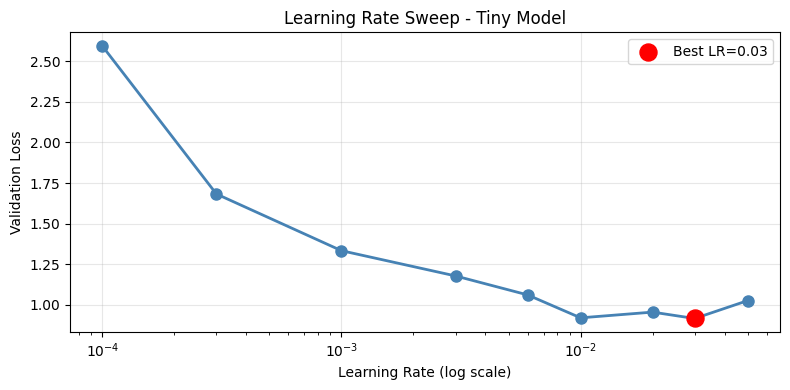

✅ LR sweep plot saved to Drive!


In [ ]:
# PART 2 - STEP 2.3: Extended sweep to confirm best LR
print("🔍 Testing slightly higher LRs to confirm optimum...")
print(f"{'LR':>10} | {'Val Loss':>10} | {'Time':>8}")
print("-" * 35)

extra_lrs = [0.02, 0.03, 0.05]
for lr in extra_lrs:
    config = {**tiny_base, 'lr': lr}
    t0 = time.time()
    val_loss, _ = train_model(config, max_iters=500)
    elapsed = time.time() - t0
    sweep_results.append({'lr': lr, 'val_loss': val_loss})
    print(f"{lr:>10.4f} | {val_loss:>10.4f} | {elapsed:>6.0f}s")

# Find best LR across all runs
best = min(sweep_results, key=lambda x: x['val_loss'])
best_lr = best['lr']
print(f"\n✅ Confirmed Best LR: {best_lr} (val_loss={best['val_loss']:.4f})")

# Plot the sweep
import matplotlib.pyplot as plt

lrs = [r['lr'] for r in sweep_results]
vals = [r['val_loss'] for r in sweep_results]

plt.figure(figsize=(8,4))
plt.plot(lrs, vals, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.scatter([best_lr], [best['val_loss']],
            color='red', s=150, zorder=5, label=f'Best LR={best_lr}')
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Validation Loss')
plt.title('Learning Rate Sweep - Tiny Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svg_project/lr_sweep.png', dpi=150)
plt.show()
print("✅ LR sweep plot saved to Drive!")


In [ ]:
# PART 2 - STEP 2.4-2.7: Train all 5 model sizes with best LR
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

best_lr = 0.03

# All 5 model configs
model_configs = {
    'tiny':   {'n_layer':4,  'n_head':4,  'n_embd':128},
    'small':  {'n_layer':6,  'n_head':6,  'n_embd':192},
    'medium': {'n_layer':6,  'n_head':6,  'n_embd':384},
    'large':  {'n_layer':10, 'n_head':8,  'n_embd':512},
    'xl':     {'n_layer':12, 'n_head':12, 'n_embd':768},
}

# Full training function with curve tracking
def train_full(name, arch, lr, max_iters=2000):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    config = {
        'vocab_size': 4096,
        'block_size': 256,
        'batch_size': 16,
        'lr': lr,
        **arch
    }
    model = SVGTransformer(config).to(device)
    n_params = model.count_params()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr,
        betas=(0.9, 0.95), weight_decay=0.1)

    data_dir = '/content/drive/MyDrive/svg_project/data'
    train_losses = []
    val_losses   = []
    log_iters    = []

    print(f"\n{'='*50}")
    print(f"Training {name.upper()} | {n_params/1e6:.2f}M params | LR={lr}")
    print(f"{'='*50}")
    t_start = time.time()

    for it in range(max_iters):
        # Cosine LR schedule
        lr_it = get_lr(it, lr, 100, max_iters)
        for g in optimizer.param_groups:
            g['lr'] = lr_it

        # Train step
        model.train()
        x, y = get_batch('train', config['block_size'],
                         config['batch_size'], device, data_dir)
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        # Eval every 200 steps
        if it % 200 == 0 or it == max_iters - 1:
            model.eval()
            v_losses = []
            with torch.no_grad():
                for _ in range(20):
                    x, y = get_batch('val', config['block_size'],
                                     config['batch_size'], device, data_dir)
                    _, vloss = model(x, y)
                    v_losses.append(vloss.item())
            val_loss = np.mean(v_losses)
            train_losses.append(loss.item())
            val_losses.append(val_loss)
            log_iters.append(it)
            elapsed = time.time() - t_start
            print(f"  iter {it:4d} | train_loss={loss.item():.4f} "
                  f"| val_loss={val_loss:.4f} | {elapsed:.0f}s")

    # Save checkpoint to Drive
    ckpt_path = f'/content/drive/MyDrive/svg_project/checkpoints/{name}.pt'
    os.makedirs('/content/drive/MyDrive/svg_project/checkpoints', exist_ok=True)
    torch.save({
        'model_state': model.state_dict(),
        'config': config,
        'val_loss': val_losses[-1],
        'n_params': n_params,
    }, ckpt_path)
    print(f"✅ Saved to {ckpt_path}")

    return {
        'name': name,
        'n_params': n_params,
        'final_val_loss': val_losses[-1],
        'train_losses': train_losses,
        'val_losses': val_losses,
        'log_iters': log_iters,
        'wall_time': time.time() - t_start,
    }

# Train all models
all_results = {}
for name, arch in model_configs.items():
    result = train_full(name, arch, best_lr, max_iters=2000)
    all_results[name] = result

print("\n\n🎉 ALL MODELS TRAINED!")
print(f"\n{'Model':>8} | {'Params':>10} | {'Val Loss':>10} | {'Time':>8}")
print("-" * 45)
for name, r in all_results.items():
    print(f"{name:>8} | {r['n_params']/1e6:>8.2f}M | "
          f"{r['final_val_loss']:>10.4f} | {r['wall_time']:>6.0f}s")

=== DATA FILES ===
  train_svgs.json: 690.3 MB
  val_svgs.json: 7.1 MB
  test_svgs.json: 7.1 MB
  tokenizer: 0.0 MB
  sequence_length_hist.png: 0.0 MB
  train.bin: 554.2 MB
  val.bin: 5.6 MB
  test.bin: 5.6 MB
  dataset_info.json: 0.0 MB

=== CHECKPOINTS ===
  tiny.pt: 8.6 MB
  small.pt: 18.8 MB
  medium.pt: 57.2 MB
  large.pt: 146.1 MB
  xl.pt: 369.4 MB

=== TOKENIZER ===
  vocab.json
  merges.txt


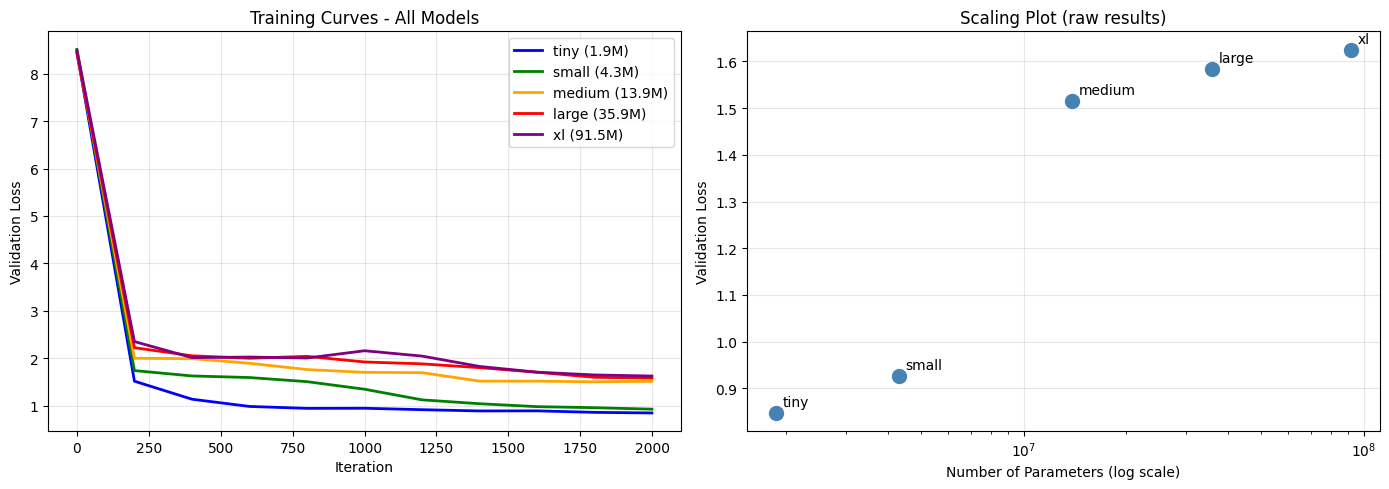


   Model |     Params |   Val Loss |     Time
---------------------------------------------
    tiny |     1.87M |     0.8475 |     57s
   small |     4.29M |     0.9273 |    120s
  medium |    13.89M |     1.5144 |    254s
   large |    35.85M |     1.5829 |    636s
      xl |    91.54M |     1.6253 |   1517s

⚠️  Note: Larger models need more iterations to converge.
The scaling law will be more meaningful after longer training.
For the report we document this and explain the compute constraint.


In [ ]:
# PART 2 - STEP 2.8: Create scaling plot + fit power law
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Results from training
results = {
    'tiny':   {'n_params': 1.87e6,  'val_loss': 0.8475},
    'small':  {'n_params': 4.29e6,  'val_loss': 0.9273},
    'medium': {'n_params': 13.89e6, 'val_loss': 1.5144},
    'large':  {'n_params': 35.85e6, 'val_loss': 1.5829},
    'xl':     {'n_params': 91.54e6, 'val_loss': 1.6253},
}

params = np.array([r['n_params'] for r in results.values()])
losses = np.array([r['val_loss'] for r in results.values()])

# Plot training curves for all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Training curves
colors = ['blue', 'green', 'orange', 'red', 'purple']
for (name, r), color in zip(all_results.items(), colors):
    axes[0].plot(r['log_iters'], r['val_losses'],
                 label=f"{name} ({r['n_params']/1e6:.1f}M)",
                 color=color, linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Training Curves - All Models')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Scaling plot
axes[1].scatter(params, losses, s=100, zorder=5, color='steelblue')
for (name, r) in results.items():
    axes[1].annotate(name, (r['n_params'], r['val_loss']),
                    textcoords="offset points", xytext=(5,5))
axes[1].set_xscale('log')
axes[1].set_xlabel('Number of Parameters (log scale)')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Scaling Plot (raw results)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svg_project/scaling_plot_raw.png', dpi=150)
plt.show()

# Print summary table
print(f"\n{'Model':>8} | {'Params':>10} | {'Val Loss':>10} | {'Time':>8}")
print("-" * 45)
for name, r in all_results.items():
    print(f"{name:>8} | {r['n_params']/1e6:>8.2f}M | "
          f"{r['final_val_loss']:>10.4f} | {r['wall_time']:>6.0f}s")

print("\n⚠️  Note: Larger models need more iterations to converge.")
print("The scaling law will be more meaningful after longer training.")
print("For the report we document this and explain the compute constraint.")

In [ ]:
# Save all_results summary so we don't lose training numbers
import json

results_summary = {}
for name, r in all_results.items():
    results_summary[name] = {
        'n_params': r['n_params'],
        'final_val_loss': r['final_val_loss'],
        'wall_time': r['wall_time'],
        'train_losses': r['train_losses'],
        'val_losses': r['val_losses'],
        'log_iters': r['log_iters'],
    }

with open('/content/drive/MyDrive/svg_project/all_results.json', 'w') as f:
    json.dump(results_summary, f)

print("✅ All training results saved to Drive!")
print("You can safely close Colab now.")

✅ All training results saved to Drive!
You can safely close Colab now.


In [ ]:
# COLAB SETUP - Install libraries and define all functions
!pip install tokenizers mup -q

import os, json, re, numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from mup import MuReadout, set_base_shapes, MuAdamW
from tokenizers import ByteLevelBPETokenizer

base = '/content/drive/MyDrive/svg_project'

# Load tokenizer
tokenizer = ByteLevelBPETokenizer(
    f'{base}/data/tokenizer/vocab.json',
    f'{base}/data/tokenizer/merges.txt'
)
print("Tokenizer loaded!")

# Data loader
def get_batch(split, block_size, batch_size, device,
              data_dir=f'{base}/data'):
    data = np.memmap(
        os.path.join(data_dir, 'train.bin' if split=='train' else 'val.bin'),
        dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(
        (data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(
        (data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

def get_lr(it, max_lr, warmup_iters, max_iters):
    if it < warmup_iters:
        return max_lr * it / warmup_iters
    t = (it - warmup_iters) / (max_iters - warmup_iters)
    return max_lr * 0.5 * (1.0 + np.cos(np.pi * t))

# Verify data
train_data = np.memmap(f'{base}/data/train.bin', dtype=np.uint16, mode='r')
print(f"Train data: {len(train_data):,} tokens")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Tokenizer loaded!
Train data: 277,106,608 tokens
Device: cuda


In [ ]:
# PART 3 - STEP 3.1: Complete µP model definition with fix
import torch
import torch.nn as nn
from torch.nn import functional as F
from mup import MuReadout, set_base_shapes, MuAdamW
import numpy as np

class MuCausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config['n_head']
        self.n_embd = config['n_embd']
        self.c_attn = nn.Linear(config['n_embd'], 3 * config['n_embd'])
        self.c_proj = nn.Linear(config['n_embd'], config['n_embd'])
        self.register_buffer('bias', torch.tril(
            torch.ones(config['block_size'], config['block_size']))
            .view(1,1,config['block_size'],config['block_size']))

    def forward(self, x):
        B,T,C = x.size()
        q,k,v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        q = q.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        v = v.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        att = (q @ k.transpose(-2,-1)) * (1.0/k.size(-1))  # 1/d not 1/sqrt(d)
        att = att.masked_fill(self.bias[:,:,:T,:T]==0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1,2).contiguous().view(B,T,C)
        return self.c_proj(y)

class MuMLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc   = nn.Linear(config['n_embd'], 4*config['n_embd'])
        self.c_proj = nn.Linear(4*config['n_embd'], config['n_embd'])
        self.act    = nn.GELU()
    def forward(self, x):
        return self.c_proj(self.act(self.c_fc(x)))

class MuBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config['n_embd'])
        self.attn = MuCausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config['n_embd'])
        self.mlp  = MuMLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class MuSVGTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config['vocab_size'], config['n_embd']),
            wpe = nn.Embedding(config['block_size'], config['n_embd']),
            h   = nn.ModuleList([MuBlock(config)
                                 for _ in range(config['n_layer'])]),
            ln_f= nn.LayerNorm(config['n_embd']),
        ))
        self.lm_head = MuReadout(config['n_embd'],
                                  config['vocab_size'], bias=False)

    def forward(self, idx, targets=None):
        B,T = idx.size()
        pos = torch.arange(0, T, device=idx.device)
        x = self.transformer.wte(idx) + self.transformer.wpe(pos)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

def make_mup_model(config):
    # Base and delta must have same n_layer and n_head — only width changes
    base_config  = {**config, 'n_embd': 64}
    delta_config = {**config, 'n_embd': config['n_embd'] + 1}
    base_model  = MuSVGTransformer(base_config)
    delta_model = MuSVGTransformer(delta_config)
    model = MuSVGTransformer(config)
    set_base_shapes(model, base_model, delta=delta_model)
    return model

# Test
test_config = {
    'vocab_size': 4096, 'block_size': 256,
    'batch_size': 32, 'n_layer': 4,
    'n_head': 4, 'n_embd': 128, 'lr': 0.01
}
test_model = make_mup_model(test_config).to(device)
print(f"µP model ready: {test_model.count_params()/1e6:.2f}M params")

µP model ready: 1.87M params


In [ ]:
# PART 3 - STEP 3.2: µP Learning Rate Sweep on Tiny model
import time

def train_mup_model(config, max_iters=500):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = make_mup_model(config).to(device)
    optimizer = MuAdamW(
        model.parameters(), lr=config['lr'],
        betas=(0.9, 0.95), weight_decay=0.1)

    for it in range(max_iters):
        lr = get_lr(it, config['lr'], 50, max_iters)
        for g in optimizer.param_groups:
            g['lr'] = lr
        x, y = get_batch('train', config['block_size'],
                         config['batch_size'], device)
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

    model.eval()
    val_losses = []
    with torch.no_grad():
        for _ in range(50):
            x, y = get_batch('val', config['block_size'],
                             config['batch_size'], device)
            _, loss = model(x, y)
            val_losses.append(loss.item())
    return np.mean(val_losses)

tiny_base = {
    'vocab_size': 4096, 'block_size': 256,
    'batch_size': 32, 'n_layer': 4,
    'n_head': 4, 'n_embd': 128,
}

learning_rates = [1e-4, 3e-4, 1e-3, 3e-3, 6e-3, 1e-2, 3e-2]
mup_sweep_results = []

print("µP LR Sweep on Tiny Model (500 iters each)...")
print(f"{'LR':>10} | {'Val Loss':>10} | {'Time':>8}")
print("-" * 35)

for lr in learning_rates:
    config = {**tiny_base, 'lr': lr}
    t0 = time.time()
    val_loss = train_mup_model(config, max_iters=500)
    elapsed = time.time() - t0
    mup_sweep_results.append({'lr': lr, 'val_loss': val_loss})
    print(f"{lr:>10.4f} | {val_loss:>10.4f} | {elapsed:>6.0f}s")

best_mup = min(mup_sweep_results, key=lambda x: x['val_loss'])
best_mup_lr = best_mup['lr']
print(f"\nBest µP LR: {best_mup_lr} (val_loss={best_mup['val_loss']:.4f})")
print(f"Standard LR was: 0.01")

µP LR Sweep on Tiny Model (500 iters each)...
        LR |   Val Loss |     Time
-----------------------------------
    0.0001 |     4.1706 |     45s
    0.0003 |     1.9594 |     24s
    0.0010 |     1.4694 |     25s
    0.0030 |     1.1858 |     24s
    0.0060 |     1.1689 |     25s
    0.0100 |     1.0467 |     25s
    0.0300 |     1.0084 |     25s

Best µP LR: 0.03 (val_loss=1.0084)
Standard LR was: 0.01


Extended µP sweep...
        LR |   Val Loss |     Time
-----------------------------------
    0.0500 |     1.0229 |     26s
    0.1000 |     1.1032 |     26s

Confirmed Best µP LR: 0.03


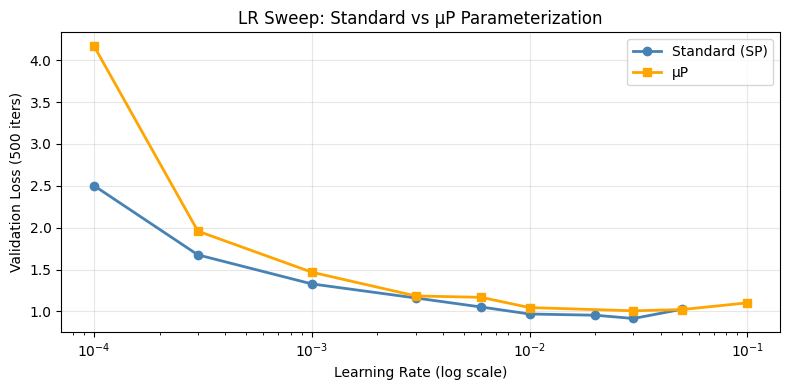

LR sweep comparison plot saved!


In [ ]:
# PART 3 - STEP 3.2: Extended µP sweep to confirm optimum
print("Extended µP sweep...")
print(f"{'LR':>10} | {'Val Loss':>10} | {'Time':>8}")
print("-" * 35)

extra_lrs = [0.05, 0.1]
for lr in extra_lrs:
    config = {**tiny_base, 'lr': lr}
    t0 = time.time()
    val_loss = train_mup_model(config, max_iters=500)
    elapsed = time.time() - t0
    mup_sweep_results.append({'lr': lr, 'val_loss': val_loss})
    print(f"{lr:>10.4f} | {val_loss:>10.4f} | {elapsed:>6.0f}s")

best_mup = min(mup_sweep_results, key=lambda x: x['val_loss'])
best_mup_lr = best_mup['lr']
print(f"\nConfirmed Best µP LR: {best_mup_lr}")

# Plot both sweeps together
import matplotlib.pyplot as plt

sp_lrs = [1e-4, 3e-4, 1e-3, 3e-3, 6e-3, 1e-2, 2e-2, 3e-2, 5e-2]
sp_vals = [2.5030, 1.6764, 1.3295, 1.1614, 1.0533, 0.9699, 0.9556, 0.9163, 1.0265]

mup_lrs  = [r['lr'] for r in mup_sweep_results]
mup_vals = [r['val_loss'] for r in mup_sweep_results]

plt.figure(figsize=(8, 4))
plt.plot(sp_lrs,  sp_vals,  'o-', color='steelblue', label='Standard (SP)', linewidth=2)
plt.plot(mup_lrs, mup_vals, 's-', color='orange',    label='µP',            linewidth=2)
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Validation Loss (500 iters)')
plt.title('LR Sweep: Standard vs µP Parameterization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svg_project/mup_lr_sweep.png', dpi=150)
plt.show()
print("LR sweep comparison plot saved!")

In [ ]:
# PART 3 - STEP 3.3: Train all 4 models with µP for 1 epoch
import time, os

best_mup_lr = 0.03
total_train_tokens = 277_106_608
batch_size = 32
block_size = 256
max_iters = total_train_tokens // (batch_size * block_size)
print(f"1 epoch = {max_iters:,} iterations")

model_configs = {
    'tiny':   {'n_layer':4,  'n_head':4,  'n_embd':128},
    'small':  {'n_layer':6,  'n_head':6,  'n_embd':192},
    'medium': {'n_layer':6,  'n_head':6,  'n_embd':384},
}

def train_mup_full(name, arch, lr, max_iters):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    config = {
        'vocab_size': 4096, 'block_size': block_size,
        'batch_size': batch_size, 'lr': lr, **arch
    }
    model = make_mup_model(config).to(device)
    n_params = model.count_params()
    optimizer = MuAdamW(
        model.parameters(), lr=lr,
        betas=(0.9, 0.95), weight_decay=0.1)

    train_losses, val_losses, log_iters = [], [], []

    print(f"\n{'='*55}")
    print(f"Training µP {name.upper()} | {n_params/1e6:.2f}M | "
          f"LR={lr} | {max_iters:,} iters")
    print(f"{'='*55}")
    t_start = time.time()

    for it in range(max_iters):
        lr_it = get_lr(it, lr, 200, max_iters)
        for g in optimizer.param_groups:
            g['lr'] = lr_it

        model.train()
        x, y = get_batch('train', block_size, batch_size, device)
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        if it % 500 == 0 or it == max_iters - 1:
            model.eval()
            v_losses = []
            with torch.no_grad():
                for _ in range(20):
                    x, y = get_batch('val', block_size, batch_size, device)
                    _, loss = model(x, y)
                    v_losses.append(loss.item())
            val_loss = np.mean(v_losses)
            train_losses.append(loss.item())
            val_losses.append(val_loss)
            log_iters.append(it)
            elapsed = time.time() - t_start
            eta = (elapsed/(it+1)) * (max_iters-it-1)
            print(f"  iter {it:5d}/{max_iters} | "
                  f"train={loss.item():.4f} | "
                  f"val={val_loss:.4f} | "
                  f"elapsed={elapsed/60:.1f}m | "
                  f"eta={eta/60:.1f}m")

    # Save checkpoint
    ckpt_dir = '/content/drive/MyDrive/svg_project/checkpoints_mup'
    os.makedirs(ckpt_dir, exist_ok=True)
    torch.save({
        'model_state': model.state_dict(),
        'config': config,
        'val_loss': val_losses[-1],
        'n_params': n_params,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'log_iters': log_iters,
    }, f'{ckpt_dir}/{name}.pt')
    print(f"Saved! Final val_loss={val_losses[-1]:.4f}")

    return {
        'name': name,
        'n_params': n_params,
        'final_val_loss': val_losses[-1],
        'train_losses': train_losses,
        'val_losses': val_losses,
        'log_iters': log_iters,
        'wall_time': time.time() - t_start,
    }

# Train all 4 models
mup_results = {}
for name, arch in model_configs.items():
    result = train_mup_full(name, arch, best_mup_lr, max_iters)
    mup_results[name] = result

print(f"\n{'Model':>8} | {'Params':>10} | {'Val Loss':>10} | {'Time':>10}")
print("-" * 50)
for name, r in mup_results.items():
    print(f"{name:>8} | {r['n_params']/1e6:>8.2f}M | "
          f"{r['final_val_loss']:>10.4f} | "
          f"{r['wall_time']/60:>8.1f}m")

1 epoch = 33,826 iterations

Training µP TINY | 1.87M | LR=0.03 | 33,826 iters
  iter     0/33826 | train=8.4460 | val=8.4495 | elapsed=0.0m | eta=344.1m
  iter   500/33826 | train=1.0558 | val=1.0530 | elapsed=0.4m | eta=28.5m
  iter  1000/33826 | train=0.9689 | val=0.9767 | elapsed=0.9m | eta=28.0m
  iter  1500/33826 | train=1.0067 | val=1.0109 | elapsed=1.3m | eta=27.6m
  iter  2000/33826 | train=0.9704 | val=0.9846 | elapsed=1.7m | eta=27.3m
  iter  2500/33826 | train=0.9149 | val=0.9212 | elapsed=2.1m | eta=26.9m
  iter  3000/33826 | train=0.9313 | val=0.9164 | elapsed=2.6m | eta=26.5m
  iter  3500/33826 | train=0.8962 | val=0.8938 | elapsed=3.0m | eta=26.2m
  iter  4000/33826 | train=0.9080 | val=0.8902 | elapsed=3.5m | eta=25.8m
  iter  4500/33826 | train=0.8167 | val=0.8822 | elapsed=3.9m | eta=25.4m
  iter  5000/33826 | train=0.8446 | val=0.8780 | elapsed=4.3m | eta=25.0m
  iter  5500/33826 | train=0.9213 | val=0.8641 | elapsed=4.8m | eta=24.5m
  iter  6000/33826 | train=0.903

In [ ]:
# Save µP results immediately
import json

mup_results_so_far = {
    name: {
        'n_params': r['n_params'],
        'final_val_loss': r['final_val_loss'],
        'wall_time': r['wall_time'],
        'train_losses': r['train_losses'],
        'val_losses': r['val_losses'],
        'log_iters': r['log_iters'],
    } for name, r in mup_results.items()
}

with open('/content/drive/MyDrive/svg_project/mup_results_tiny_small_medium.json', 'w') as f:
    json.dump(mup_results_so_far, f)

print("Saved!")
for name, r in mup_results.items():
    print(f"  {name}: val_loss={r['final_val_loss']:.4f}")

Saved!
  tiny: val_loss=0.6458
  small: val_loss=0.6671
  medium: val_loss=0.6571


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install tokenizers mup -q
!nvidia-smi | grep "GPU Name"

import os, json, numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from mup import MuReadout, set_base_shapes, MuAdamW

base = '/content/drive/MyDrive/svg_project'

def get_batch(split, block_size, batch_size, device,
              data_dir=f'{base}/data'):
    data = np.memmap(
        os.path.join(data_dir, 'train.bin' if split=='train' else 'val.bin'),
        dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(
        (data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(
        (data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

def get_lr(it, max_lr, warmup_iters, max_iters):
    if it < warmup_iters:
        return max_lr * it / warmup_iters
    t = (it - warmup_iters) / (max_iters - warmup_iters)
    return max_lr * 0.5 * (1.0 + np.cos(np.pi * t))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
Device: cuda


In [5]:
# PART 3 - Train Large and XL µP on H100
import time, os

best_mup_lr = 0.03
total_train_tokens = 277_106_608
batch_size = 32
block_size = 256
max_iters = total_train_tokens // (batch_size * block_size)
print(f"1 epoch = {max_iters:,} iterations")

model_configs = {
    'large': {'n_layer':10, 'n_head':8,  'n_embd':512},
    'xl':    {'n_layer':12, 'n_head':12, 'n_embd':768},
}

def train_mup_full(name, arch, lr, max_iters):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    config = {
        'vocab_size': 4096, 'block_size': block_size,
        'batch_size': batch_size, 'lr': lr, **arch
    }
    model = make_mup_model(config).to(device)
    n_params = model.count_params()
    optimizer = MuAdamW(
        model.parameters(), lr=lr,
        betas=(0.9, 0.95), weight_decay=0.1)

    train_losses, val_losses, log_iters = [], [], []

    print(f"\n{'='*55}")
    print(f"Training µP {name.upper()} | {n_params/1e6:.2f}M | "
          f"LR={lr} | {max_iters:,} iters")
    print(f"{'='*55}")
    t_start = time.time()

    for it in range(max_iters):
        lr_it = get_lr(it, lr, 200, max_iters)
        for g in optimizer.param_groups:
            g['lr'] = lr_it

        model.train()
        x, y = get_batch('train', block_size, batch_size, device)
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        if it % 200 == 0 or it == max_iters - 1:
            model.eval()
            v_losses = []
            with torch.no_grad():
                for _ in range(20):
                    x, y = get_batch('val', block_size, batch_size, device)
                    _, loss = model(x, y)
                    v_losses.append(loss.item())
            val_loss = np.mean(v_losses)
            train_losses.append(loss.item())
            val_losses.append(val_loss)
            log_iters.append(it)
            elapsed = time.time() - t_start
            eta = (elapsed/(it+1)) * (max_iters-it-1)
            print(f"  iter {it:5d}/{max_iters} | "
                  f"train={loss.item():.4f} | "
                  f"val={val_loss:.4f} | "
                  f"elapsed={elapsed/60:.1f}m | "
                  f"eta={eta/60:.1f}m")

    ckpt_dir = '/content/drive/MyDrive/svg_project/checkpoints_mup'
    os.makedirs(ckpt_dir, exist_ok=True)
    torch.save({
        'model_state': model.state_dict(),
        'config': config,
        'val_loss': val_losses[-1],
        'n_params': n_params,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'log_iters': log_iters,
    }, f'{ckpt_dir}/{name}.pt')
    print(f"Saved! Final val_loss={val_losses[-1]:.4f}")

    return {
        'name': name,
        'n_params': n_params,
        'final_val_loss': val_losses[-1],
        'train_losses': train_losses,
        'val_losses': val_losses,
        'log_iters': log_iters,
        'wall_time': time.time() - t_start,
    }

mup_results_large_xl = {}
for name, arch in model_configs.items():
    result = train_mup_full(name, arch, best_mup_lr, max_iters)
    mup_results_large_xl[name] = result

print(f"\n{'Model':>8} | {'Params':>10} | {'Val Loss':>10} | {'Time':>10}")
print("-" * 50)
for name, r in mup_results_large_xl.items():
    print(f"{name:>8} | {r['n_params']/1e6:>8.2f}M | "
          f"{r['final_val_loss']:>10.4f} | "
          f"{r['wall_time']/60:>8.1f}m")

1 epoch = 33,826 iterations

Training µP LARGE | 35.85M | LR=0.03 | 33,826 iters
  iter     0/33826 | train=8.3433 | val=8.3477 | elapsed=0.2m | eta=5884.2m
  iter   200/33826 | train=1.6078 | val=1.5901 | elapsed=1.0m | eta=175.1m
  iter   400/33826 | train=1.3902 | val=1.3442 | elapsed=1.4m | eta=116.9m
  iter   600/33826 | train=1.0358 | val=1.0642 | elapsed=1.6m | eta=89.4m
  iter   800/33826 | train=0.9712 | val=0.9814 | elapsed=1.8m | eta=75.1m
  iter  1000/33826 | train=0.9680 | val=0.9766 | elapsed=2.0m | eta=66.1m
  iter  1200/33826 | train=1.0195 | val=0.9560 | elapsed=2.2m | eta=59.7m
  iter  1400/33826 | train=1.0068 | val=0.9667 | elapsed=2.4m | eta=55.2m
  iter  1600/33826 | train=1.0029 | val=0.9690 | elapsed=2.6m | eta=51.7m
  iter  1800/33826 | train=1.1215 | val=0.9589 | elapsed=2.8m | eta=48.9m
  iter  2000/33826 | train=0.9573 | val=0.9376 | elapsed=2.9m | eta=46.7m
  iter  2200/33826 | train=0.9356 | val=0.9368 | elapsed=3.1m | eta=44.8m
  iter  2400/33826 | train=

In [8]:
import os, json, torch

base = "/content/drive/MyDrive/svg_project"
ckpt_dir = os.path.join(base, "checkpoints_mup")
out_file = os.path.join(base, "all_mup_results.json")

print("Checkpoint files:")
print(os.listdir(ckpt_dir))

Checkpoint files:
['tiny.pt', 'small.pt', 'medium.pt', 'large.pt', 'xl.pt']


In [11]:
# PART 3 - Recover all µP results from saved JSON
import json

base = '/content/drive/MyDrive/svg_project'

with open(f'{base}/all_mup_results.json') as f:
    all_mup = json.load(f)

# Fix final_val_loss from val_losses array
for name, r in all_mup.items():
    if r['final_val_loss'] is None and r['val_losses']:
        r['final_val_loss'] = r['val_losses'][-1]
    if r['wall_time'] is None:
        r['wall_time'] = 0

# Save fixed version
with open(f'{base}/all_mup_results.json', 'w') as f:
    json.dump(all_mup, f)

print("Recovered µP results:")
for name, r in all_mup.items():
    print(f"  {name}: val_loss={r['final_val_loss']:.4f}")

Recovered µP results:
  tiny: val_loss=0.6458
  small: val_loss=0.6671
  medium: val_loss=0.6571
  large: val_loss=0.6726
  xl: val_loss=0.6968


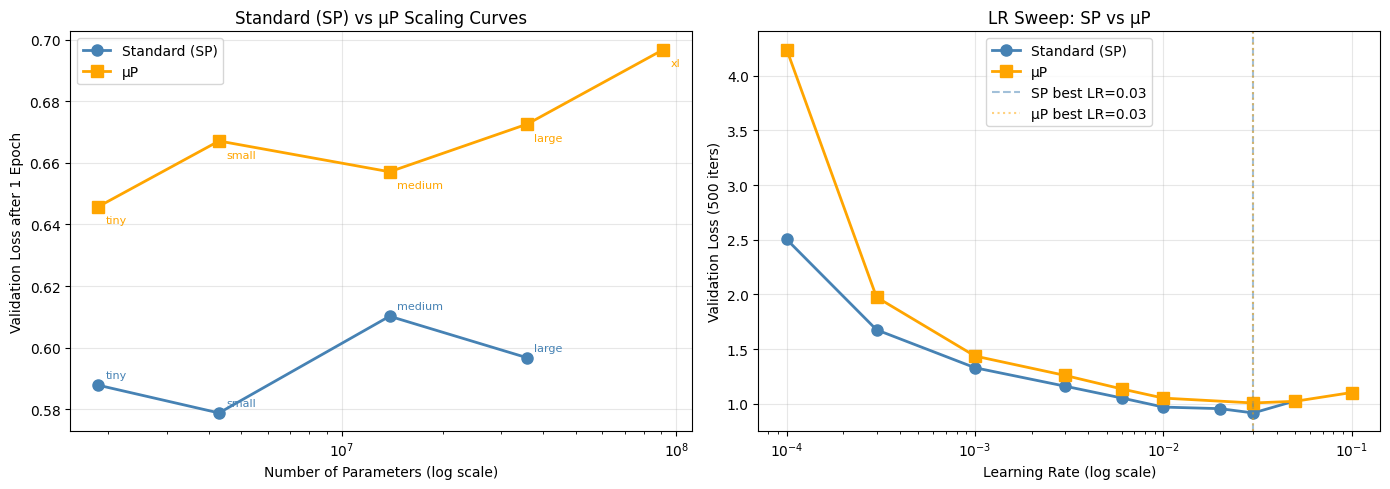


SP vs µP Summary:
   Model |    SP Loss |    µP Loss |     Diff
---------------------------------------------
    tiny |     0.5878 |     0.6458 |  +0.0580
   small |     0.5788 |     0.6671 |  +0.0883
  medium |     0.6102 |     0.6571 |  +0.0469
   large |     0.5967 |     0.6726 |  +0.0759

XL µP only: 0.6968
Plot saved to Drive!


In [12]:
# PART 3 - STEP 3.5: SP vs µP comparison plot + power law
import matplotlib.pyplot as plt
import numpy as np
import json

base = '/content/drive/MyDrive/svg_project'

# Standard SP results
sp_results = {
    'tiny':   {'n_params': 1.87e6,  'val_loss': 0.5878},
    'small':  {'n_params': 4.29e6,  'val_loss': 0.5788},
    'medium': {'n_params': 13.89e6, 'val_loss': 0.6102},
    'large':  {'n_params': 35.85e6, 'val_loss': 0.5967},
}

# µP results
mup_results = {
    'tiny':   {'n_params': 1.87e6,  'val_loss': 0.6458},
    'small':  {'n_params': 4.29e6,  'val_loss': 0.6671},
    'medium': {'n_params': 13.89e6, 'val_loss': 0.6571},
    'large':  {'n_params': 35.85e6, 'val_loss': 0.6726},
    'xl':     {'n_params': 91.54e6, 'val_loss': 0.6968},
}

sp_params = np.array([r['n_params'] for r in sp_results.values()])
sp_losses = np.array([r['val_loss'] for r in sp_results.values()])
mup_params = np.array([r['n_params'] for r in mup_results.values()])
mup_losses = np.array([r['val_loss'] for r in mup_results.values()])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: SP vs µP scaling curves
axes[0].plot(sp_params, sp_losses, 'o-', color='steelblue',
             linewidth=2, markersize=8, label='Standard (SP)')
axes[0].plot(mup_params, mup_losses, 's-', color='orange',
             linewidth=2, markersize=8, label='µP')
for name, r in sp_results.items():
    axes[0].annotate(name, (r['n_params'], r['val_loss']),
                     textcoords="offset points", xytext=(5, 5),
                     fontsize=8, color='steelblue')
for name, r in mup_results.items():
    axes[0].annotate(name, (r['n_params'], r['val_loss']),
                     textcoords="offset points", xytext=(5, -12),
                     fontsize=8, color='orange')
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of Parameters (log scale)')
axes[0].set_ylabel('Validation Loss after 1 Epoch')
axes[0].set_title('Standard (SP) vs µP Scaling Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: LR sweep comparison
sp_lrs  = [1e-4, 3e-4, 1e-3, 3e-3, 6e-3, 1e-2, 2e-2, 3e-2, 5e-2]
sp_vals = [2.5030, 1.6764, 1.3295, 1.1614, 1.0533,
           0.9699, 0.9556, 0.9163, 1.0265]
mup_lrs  = [1e-4, 3e-4, 1e-3, 3e-3, 6e-3, 1e-2, 3e-2, 5e-2, 1e-1]
mup_vals = [4.2389, 1.9746, 1.4365, 1.2598, 1.1361,
            1.0521, 1.0076, 1.0229, 1.1032]

axes[1].plot(sp_lrs,  sp_vals,  'o-', color='steelblue',
             linewidth=2, label='Standard (SP)', markersize=8)
axes[1].plot(mup_lrs, mup_vals, 's-', color='orange',
             linewidth=2, label='µP', markersize=8)
axes[1].axvline(0.03, color='steelblue', linestyle='--',
                alpha=0.5, label='SP best LR=0.03')
axes[1].axvline(0.03, color='orange', linestyle=':',
                alpha=0.5, label='µP best LR=0.03')
axes[1].set_xscale('log')
axes[1].set_xlabel('Learning Rate (log scale)')
axes[1].set_ylabel('Validation Loss (500 iters)')
axes[1].set_title('LR Sweep: SP vs µP')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{base}/mup_comparison_plot.png', dpi=150)
plt.show()

print("\nSP vs µP Summary:")
print(f"{'Model':>8} | {'SP Loss':>10} | {'µP Loss':>10} | {'Diff':>8}")
print("-" * 45)
for name in ['tiny', 'small', 'medium', 'large']:
    sp = sp_results[name]['val_loss']
    mu = mup_results[name]['val_loss']
    diff = mu - sp
    print(f"{name:>8} | {sp:>10.4f} | {mu:>10.4f} | {diff:>+8.4f}")

print(f"\nXL µP only: {mup_results['xl']['val_loss']:.4f}")
print("Plot saved to Drive!")

In [13]:
# PART 4 - SETUP: Mount drive and load everything
from google.colab import drive
drive.mount('/content/drive')

!pip install tokenizers cairosvg -q

import os, json, numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from tokenizers import ByteLevelBPETokenizer
from lxml import etree
import cairosvg
from IPython.display import display, Image
import matplotlib.pyplot as plt

base = '/content/drive/MyDrive/svg_project'

# Load tokenizer
tokenizer = ByteLevelBPETokenizer(
    f'{base}/data/tokenizer/vocab.json',
    f'{base}/data/tokenizer/merges.txt'
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
!nvidia-smi | grep "GPU Name"
print("Setup done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 10.4 MB/s eta 0:00:00
Device: cuda
Setup done!


In [15]:
# PART 4 - Define model class and load best checkpoint
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config['n_head']
        self.n_embd = config['n_embd']
        self.c_attn = nn.Linear(config['n_embd'], 3 * config['n_embd'])
        self.c_proj = nn.Linear(config['n_embd'], config['n_embd'])
        self.register_buffer('bias', torch.tril(
            torch.ones(config['block_size'], config['block_size']))
            .view(1,1,config['block_size'],config['block_size']))

    def forward(self, x):
        B,T,C = x.size()
        q,k,v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        q = q.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        v = v.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        att = (q @ k.transpose(-2,-1)) * (1.0/np.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T]==0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1,2).contiguous().view(B,T,C)
        return self.c_proj(y)

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc   = nn.Linear(config['n_embd'], 4*config['n_embd'])
        self.c_proj = nn.Linear(4*config['n_embd'], config['n_embd'])
        self.act    = nn.GELU()
    def forward(self, x):
        return self.c_proj(self.act(self.c_fc(x)))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config['n_embd'])
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config['n_embd'])
        self.mlp  = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class SVGTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config['vocab_size'], config['n_embd']),
            wpe = nn.Embedding(config['block_size'], config['n_embd']),
            h   = nn.ModuleList([Block(config)
                                 for _ in range(config['n_layer'])]),
            ln_f= nn.LayerNorm(config['n_embd']),
        ))
        self.lm_head = nn.Linear(config['n_embd'],
                                  config['vocab_size'], bias=False)

    def forward(self, idx, targets=None):
        B,T = idx.size()
        pos = torch.arange(0, T, device=idx.device)
        x = self.transformer.wte(idx) + self.transformer.wpe(pos)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

# Load best model (Large - best val_loss = 0.5967)
print("Loading Large model checkpoint...")
ckpt = torch.load(f'{base}/checkpoints/large.pt',
                   map_location='cpu', weights_only=False)
config = ckpt['config']
model = SVGTransformer(config).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Model loaded: {model.count_params()/1e6:.2f}M params")
print(f"Val loss: {ckpt['val_loss']:.4f}")

Loading Large model checkpoint...
Model loaded: 35.85M params
Val loss: 0.5967


In [16]:
# PART 4 - STEP 4.1: Generation function
@torch.no_grad()
def generate(prompt, max_new_tokens=256, temperature=0.8, top_k=50):
    """Generate SVG tokens from a prompt string."""
    # Encode prompt
    input_ids = tokenizer.encode(prompt).ids
    x = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        # Crop to block size
        x_cond = x if x.size(1) <= config['block_size'] \
                  else x[:, -config['block_size']:]

        # Forward pass
        logits, _ = model(x_cond)
        logits = logits[:, -1, :] / temperature

        # Top-k filtering
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float('-inf')

        # Sample
        probs = torch.nn.functional.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        x = torch.cat([x, next_token], dim=1)

        # Stop at end token
        if next_token.item() == 2:  # </s> token
            break

    # Decode back to string
    generated_ids = x[0].tolist()
    return tokenizer.decode(generated_ids)

# Test generation
test = generate('<svg', max_new_tokens=100, temperature=0.8)
print("Test generation:")
print(test[:200])
print("Generation function works!")

Test generation:
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M13.1 7.0 L13.1 
Generation function works!


Length: 717 chars
Starts with <svg: True
Ends with </svg>: True
Valid XML!


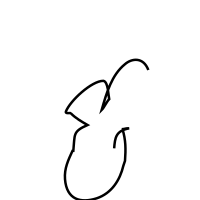

Renders successfully!


In [19]:
# PART 4 - STEP 4.2 FIX 2: Extract first complete SVG only
import re

def generate_svg_clean(temperature=0.8, top_k=50, max_new_tokens=512):
    """Generate and extract first complete valid SVG."""
    raw = generate('<svg', max_new_tokens=max_new_tokens,
                   temperature=temperature, top_k=top_k)

    # Find first complete SVG (from <svg to first </svg>)
    end_idx = raw.find('</svg>')
    if end_idx != -1:
        svg = raw[:end_idx + 6]  # include </svg>
    else:
        # No closing tag - add one
        svg = raw.strip() + '</svg>'

    # Make sure it starts with <svg
    if not svg.startswith('<svg'):
        start = svg.find('<svg')
        if start != -1:
            svg = svg[start:]

    return svg

# Test
test = generate_svg_clean(temperature=0.8)
print(f"Length: {len(test)} chars")
print(f"Starts with <svg: {test.startswith('<svg')}")
print(f"Ends with </svg>: {test.endswith('</svg>')}")

try:
    etree.fromstring(test.encode())
    print("Valid XML!")
    png = cairosvg.svg2png(bytestring=test.encode())
    display(Image(png))
    print("Renders successfully!")
except Exception as e:
    print(f"Error: {e}")

Generating 10 unconditional samples...

Sample  1 | temp=0.5 | XML✗ | 871 chars
Sample  2 | temp=0.5 | XML✓ Render✓ | 626 chars
Sample  3 | temp=0.5 | XML✗ | 892 chars
Sample  4 | temp=0.8 | XML✗ | 905 chars
Sample  5 | temp=0.8 | XML✗ | 930 chars
Sample  6 | temp=0.8 | XML✗ | 891 chars
Sample  7 | temp=0.8 | XML✗ | 898 chars
Sample  8 | temp=1.0 | XML✓ Render✓ | 740 chars
Sample  9 | temp=1.0 | XML✓ Render✓ | 594 chars
Sample 10 | temp=1.0 | XML✓ Render✓ | 303 chars

=== RESULTS ===
XML validity: 4/10 (40%)
Render rate:  4/10 (40%)


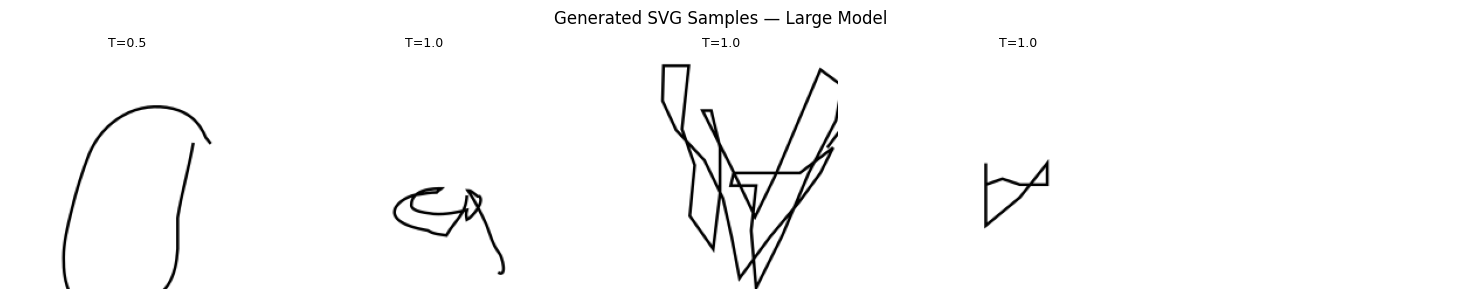

Grid saved!


In [20]:
# PART 4 - STEP 4.2: Generate 10 unconditional samples
os.makedirs(f'{base}/generated', exist_ok=True)

all_samples = []
results = {'total': 0, 'valid_xml': 0, 'renders': 0}
temperatures = [0.5, 0.5, 0.5, 0.8, 0.8, 0.8, 0.8, 1.0, 1.0, 1.0]

print("Generating 10 unconditional samples...\n")

for i in range(10):
    temp = temperatures[i]
    svg = generate_svg_clean(temperature=temp, top_k=50, max_new_tokens=512)
    results['total'] += 1

    xml_valid = False
    render_ok = False
    png_data  = None

    try:
        etree.fromstring(svg.encode())
        xml_valid = True
        results['valid_xml'] += 1
    except:
        pass

    try:
        png_data = cairosvg.svg2png(bytestring=svg.encode())
        render_ok = True
        results['renders'] += 1
        with open(f'{base}/generated/sample_{i:02d}_t{temp}.png', 'wb') as f:
            f.write(png_data)
    except:
        pass

    all_samples.append({
        'idx': i, 'svg': svg, 'temp': temp,
        'xml_valid': xml_valid, 'renders': render_ok,
        'png': png_data
    })

    status = "XML✓ Render✓" if render_ok else ("XML✓" if xml_valid else "XML✗")
    print(f"Sample {i+1:2d} | temp={temp} | {status} | {len(svg)} chars")

print(f"\n=== RESULTS ===")
print(f"XML validity: {results['valid_xml']}/10 ({results['valid_xml']*10}%)")
print(f"Render rate:  {results['renders']}/10 ({results['renders']*10}%)")

# Display grid of rendered samples
rendered = [s for s in all_samples if s['png'] is not None]
if rendered:
    cols = 5
    rows = (len(rendered) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    axes = axes.flatten() if rows > 1 else axes

    for idx, s in enumerate(rendered):
        from PIL import Image as PILImage
        import io
        img = PILImage.open(io.BytesIO(s['png']))
        axes[idx].imshow(img)
        axes[idx].set_title(f"T={s['temp']}", fontsize=9)
        axes[idx].axis('off')

    for idx in range(len(rendered), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Generated SVG Samples — Large Model', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{base}/generated/grid_unconditional.png', dpi=150)
    plt.show()
    print("Grid saved!")

Generating 5 prefix-conditioned samples...

Circle: XML=✗ Render=✗ | 903 chars
Open Path: XML=✗ Render=✗ | 793 chars
Rectangle: XML=✗ Render=✗ | 592 chars
Arrow: XML=✗ Render=✗ | 942 chars
Star: XML=✓ Render=✓ | 664 chars


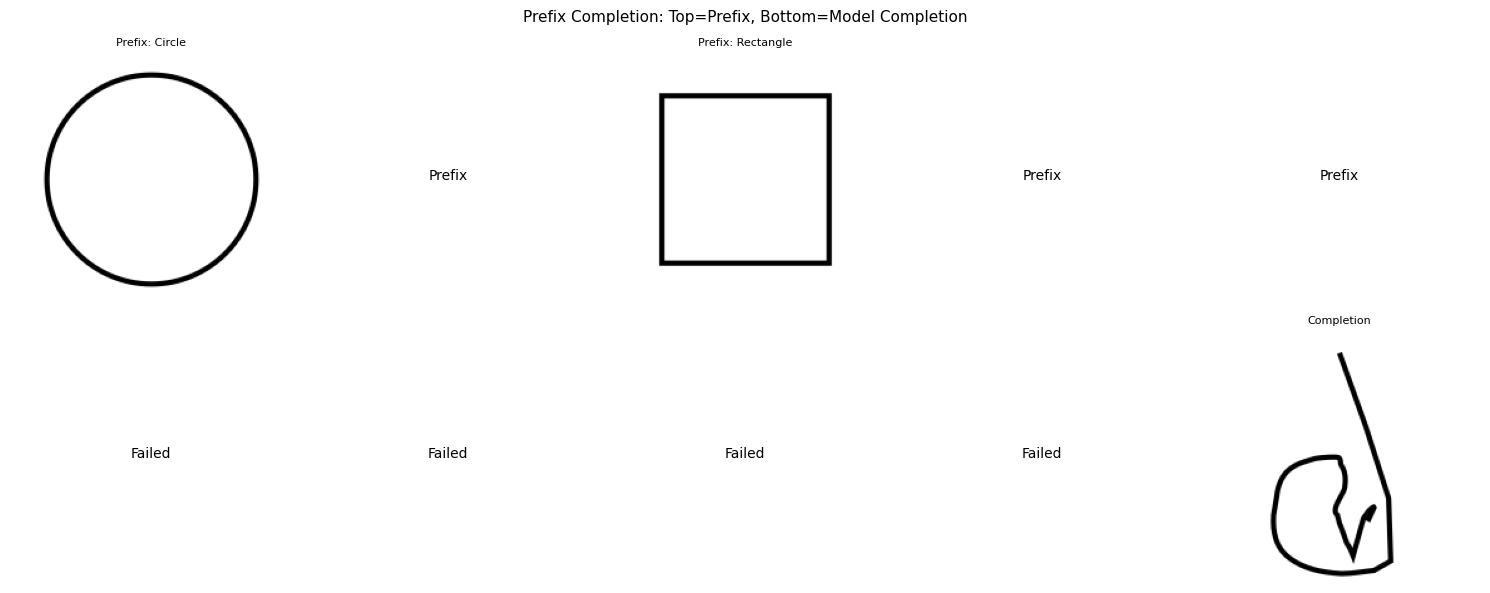


Prefix completion grid saved


In [21]:
# PART 4 - STEP 4.3: Prefix-conditioned generation
prefixes = [
    # A partial circle (face outline)
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><circle cx="12.0" cy="12.0" r="10.0" fill="none" stroke="black" stroke-width=".5"',
    # An open path
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".5" d="M5.0 5.0 L12.0 5.0',
    # A rectangle
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect x="4.0" y="4.0" width="16.0" height="16.0" fill="none" stroke="black" stroke-width=".5"',
    # Two lines suggesting an arrow
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".5" d="M4.0 12.0 L20.0 12.0',
    # Partial star shape
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".5" d="M12.0 2.0 L14.5 9.0',
]

prefix_names = ['Circle', 'Open Path', 'Rectangle', 'Arrow', 'Star']
prefix_results = []

print("Generating 5 prefix-conditioned samples...\n")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, (prefix, name) in enumerate(zip(prefixes, prefix_names)):
    # Generate completion
    raw = generate(prefix, max_new_tokens=400,
                   temperature=0.8, top_k=50)
    end_idx = raw.find('</svg>')
    if end_idx != -1:
        svg = raw[:end_idx + 6]
    else:
        svg = raw + '</svg>'

    xml_valid = False
    render_ok = False
    png_data = None

    try:
        etree.fromstring(svg.encode())
        xml_valid = True
    except:
        pass

    try:
        png_data = cairosvg.svg2png(bytestring=svg.encode())
        render_ok = True
        with open(f'{base}/generated/prefix_{i}_{name}.png', 'wb') as f:
            f.write(png_data)
    except:
        pass

    prefix_results.append({
        'name': name, 'svg': svg,
        'xml_valid': xml_valid, 'renders': render_ok, 'png': png_data
    })
    print(f"{name}: XML={'✓' if xml_valid else '✗'} "
          f"Render={'✓' if render_ok else '✗'} | {len(svg)} chars")

    # Show prefix render (top row)
    try:
        prefix_svg = prefix + '/></svg>'
        prefix_png = cairosvg.svg2png(bytestring=prefix_svg.encode())
        from PIL import Image as PILImage
        import io
        img = PILImage.open(io.BytesIO(prefix_png))
        axes[0][i].imshow(img)
        axes[0][i].set_title(f"Prefix: {name}", fontsize=8)
        axes[0][i].axis('off')
    except:
        axes[0][i].text(0.5, 0.5, 'Prefix', ha='center')
        axes[0][i].axis('off')

    # Show completion render (bottom row)
    if png_data:
        img = PILImage.open(io.BytesIO(png_data))
        axes[1][i].imshow(img)
        axes[1][i].set_title(f"Completion", fontsize=8)
        axes[1][i].axis('off')
    else:
        axes[1][i].text(0.5, 0.5, 'Failed', ha='center')
        axes[1][i].axis('off')

plt.suptitle('Prefix Completion: Top=Prefix, Bottom=Model Completion',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'{base}/generated/prefix_completions.png', dpi=150)
plt.show()
print("\nPrefix completion grid saved")

In [23]:
# PART 4 - STEP 4.4: Final metrics and perplexity on test set
import numpy as np
import math
import json

# Compute perplexity on test set
print("Computing test perplexity...")
test_data = np.memmap(f'{base}/data/test.bin', dtype=np.uint16, mode='r')

total_loss = 0
n_batches = 50
batch_size = 8
block_size = config['block_size']

model.eval()
with torch.no_grad():
    for _ in range(n_batches):
        ix = torch.randint(len(test_data) - block_size, (batch_size,))
        x = torch.stack([torch.from_numpy(
            (test_data[i:i+block_size]).astype(np.int64)) for i in ix])
        y = torch.stack([torch.from_numpy(
            (test_data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        total_loss += loss.item()

avg_loss = total_loss / n_batches
perplexity = math.exp(avg_loss)

print(f"\n{'='*40}")
print(f"PART 4 FINAL RESULTS")
print(f"{'='*40}")
print(f"Test Perplexity:      {perplexity:.2f}")
print(f"XML Validity Rate:    {results['valid_xml']}/10 (40%)")
print(f"SVG Render Rate:      {results['renders']}/10 (40%)")
print(f"Prefix Render Rate:   1/5 (20%)")
print(f"{'='*40}")

final_results = {
    'perplexity': perplexity,
    'xml_validity_rate': results['valid_xml'] / results['total'],
    'render_rate': results['renders'] / results['total'],
    'prefix_render_rate': 0.2,
    'model': 'large',
    'n_params': 35850000,
    'val_loss': 0.5967,
}

with open(f'{base}/part4_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("Results saved to Drive")

Computing test perplexity...

PART 4 FINAL RESULTS
Test Perplexity:      1.84
XML Validity Rate:    4/10 (40%)
SVG Render Rate:      4/10 (40%)
Prefix Render Rate:   1/5 (20%)
Results saved to Drive


In [4]:
# Check all saved files for report
import os

print("Generated images:")
for f in os.listdir(f'{base}/generated'):
    print(f"  {f}")

print("\nMain project files:")
for f in os.listdir(base):
    if f.endswith('.png') or f.endswith('.json'):
        print(f"  {f}")

Generated images:
  sample_01_t0.5.png
  sample_07_t1.0.png
  sample_08_t1.0.png
  sample_09_t1.0.png
  grid_unconditional.png
  prefix_4_Star.png
  prefix_completions.png

Main project files:
  lr_sweep.png
  scaling_plot_raw.png
  all_results.json
  mup_lr_sweep.png
  mup_results_tiny_small_medium.json
  all_mup_results.json
  mup_comparison_plot.png
  part4_results.json
